# Step 1 : Import Required Libraries

In [2]:
# Install SQLite3
import sqlite3

# Install Pandas for Data Analysis
import pandas as pd

# Install Matplotlib and Seaborn for Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# This method hides any warnings in Jupyter Notebook
import warnings
warnings.filterwarnings("ignore")

# Step 2 : Create a New SQLite Database and a Table

In [3]:
# Connect to SQLite Database
conn = sqlite3.connect("customer_data.db")

# Create a Cursor to interact with the database
cursor = conn.cursor()

# Create a Sample Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS customers (
id INTEGER PRIMARY KEY AUTOINCREMENT, 
name TEXT, 
age INTEGER, 
city TEXT, 
total_spent REAL
)
""")

# Commit and Close the Connection
conn.commit()

# Step 3: Insert Sample Data into the SQL Table

In [4]:
# Insert Sample Data

customers = [
("Alice Johnson", 28, "New York", 500.75), 
("Bob Smith", 35, "Los Angeles", 1200.50), 
("Charlie Brown", 22, "Chicago", 330.40), 
("David White", 40, "Houtson", 980.90), 
("Emma Wilson", 31, "San Francisco", 700.60)
]

# Insert Data into Table
cursor.executemany("INSERT INTO customers(name, age, city, total_spent) VALUES(?, ?, ?, ?)", customers)

# Step 4 : Run SQL Queries Inside Jupyter Notebook

In [5]:
# Run a SQL Query to retrieve all customers data
query = "SELECT * FROM customers"
df = pd.read_sql(query, conn) # Store query results in a Pandas Dataframe

# Display the Data
df.head()

,id,name,city,total_spent,age
0,1,Alice Johnson,New York,500.75,28
1,2,Bob Smith,Los Angeles,1200.50,35
2,3,Charlie Brown,Chicago,330.40,22
3,4,David White,Houtson,980.90,40
4,5,Emma Wilson,San Francisco,700.60,31


# Step 5 : Perform Data Analysis Using SQL Queries

In [6]:
query = "SELECT * FROM customers WHERE total_spent > 500"
df = pd.read_sql(query, conn)

In [7]:
# Display the Data
df.head()

,id,name,city,total_spent,age
0,1,Alice Johnson,New York,500.75,28
1,2,Bob Smith,Los Angeles,1200.50,35
2,4,David White,Houtson,980.90,40
3,5,Emma Wilson,San Francisco,700.60,31


In [8]:
query = "SELECT * FROM customers WHERE total_spent < 500"
df = pd.read_sql(query, conn)

In [9]:
# Display the Data
df.head()

,id,name,city,total_spent,age
0,3,Charlie Brown,Chicago,330.4,22


In [11]:
# Find the average customer age
query = "SELECT AVG(age) AS average_age FROM customers"
df = pd.read_sql(query, conn)

# Display the Data
df.head()

,average_age
0,31.2


# Step 6 : Visualizing SQL Query Results Using Python

In [12]:
query = "SELECT city, SUM(total_spent) AS total_sales FROM customers GROUP BY city"
df_sales = pd.read_sql(query, conn)

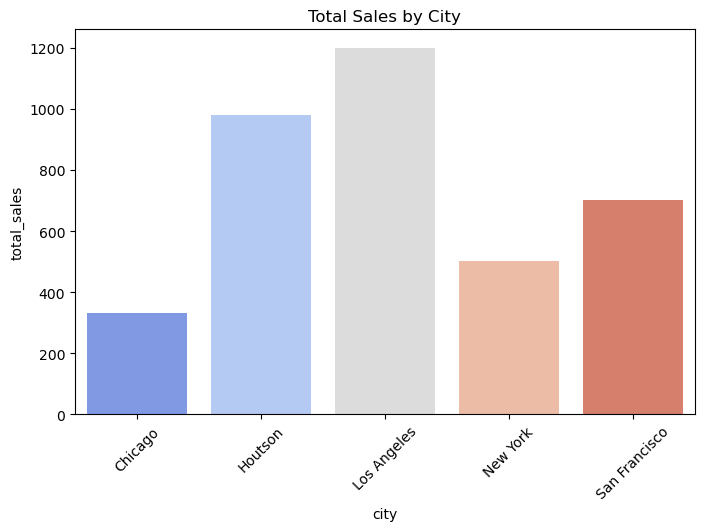

In [14]:
# Plot the Data
plt.figure(figsize=(8,5))
sns.barplot(x = "city", y = "total_sales", data = df_sales, palette = "coolwarm")
plt.xticks(rotation=45)
plt.title("Total Sales by City")
plt.show()

# Step 7 : Close the SQL Connection

In [15]:
conn.close()